# Phase 1: Data Exploration & Quality Assessment

This section covers the initial exploratory data analysis (EDA) for the Fashion and Beauty supply chain dataset, following the plan in ds_proposal.md.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data analysis and visualization.

In [13]:
# Import Required Libraries
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import datetime

# Set visualization style
sns.set(style="whitegrid")

## 2. Load DataSets

In [31]:
# 2. Load Dataset
df = pd.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df_data_co_supply_chain_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df_data_co_supply_chain_pl.columns

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

(180519, 53)

In [6]:
irrelevant_columns = []
for column in df_data_co_supply_chain_pl.columns:
    if df_data_co_supply_chain_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_co_supply_chain_pl[column][0]}")
       irrelevant_columns.append(column)

2026-04-15 17:23:37.554 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-15 17:23:37.560 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX


2026-04-15 17:23:37.606 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-15 17:23:37.615 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [7]:
df_data_future_data_chain_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/future_data.csv', encoding='latin1')
df_data_future_data_chain_pl.head(5)


Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
str,i64,i64,f64,f64,str,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,str,f64,f64,str,str,str,i64,str,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,str,str,str,str,i64,i64,str,str,str,f64,i64,str,str
"""PAYMENT""",4,4,14.07,48.5,"""Shipping on time""",0,24,"""Women's Apparel""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,5,"""Golf""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,502,1.5,0.03,15234,50.0,0.29,1,50.0,48.5,14.07,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",4,4,16.6,165.990005,"""Shipping on time""",0,48,"""Water Sports""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,7,"""Fan Shop""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,1073,34.0,0.17,15236,199.990005,0.1,1,199.990005,165.990005,16.6,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",4,4,70.519997,163.990005,"""Shipping on time""",0,48,"""Water Sports""","""La Habra""","""EE. UU.""","""XXXXXXXXX""","""Beverly""",9100,"""Smith""","""XXXXXXXXX""","""Consumer""","""CA""","""403 Tawny Hills By-pass""",90631.0,7,"""Fan Shop""",33.939163,-117.949554,"""LATAM""","""Salvador""","""Brasil""",9100,"""2015-03-31 00:03:00""",6098,1073,36.0,0.18,15235,199.990005,0.43,1,199.990005,163.990005,70.519997,"""South America""","""Bahía""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""4/4/2015 0:03""","""Standard Class"""
"""PAYMENT""",5,4,53.200001,190.0,"""Late delivery""",1,24,"""Women's Apparel""","""Mount Prospect""","""EE. UU.""","""XXXXXXXXX""","""Karen""",2552,"""Smith""","""XXXXXXXXX""","""Consumer""","""IL""","""2877 Thunder Spring Isle""",60056.0,5,"""Golf""",42.036205,-87.961433,"""LATAM""","""Santo Domingo""","""República Dominicana""",2552,"""2015-03-31 00:24:00""",6099,502,10.0,0.05,15239,50.0,0.28,4,200.0,190.0,53.200001,"""Caribbean""","""Santo Domingo""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""4/5/2015 0:24""","""Standard Class"""
"""PAYMENT""",5,4,78.660004,167.369995,"""Late delivery""",1,17,"""Cleats""","""Mount Prospect""","""EE. UU.""","""XXXXXXXXX""","""Karen""",2552,"""Smith""","""XXXXXXXXX""","""Consumer""","""IL""","""2877 Thunder Spring Isle""",60056.0,4,"""Apparel""",42.036205,-87.961433,"""LATAM""","""Santo Domingo""","""República Dominicana""",2552,"""2015-03-31 00:24:00""",6099,365,12.6,0.07,15237,59.990002,0.47,3,179.970001,167.369995,78.660004,"""Caribbean""","""Santo Domingo""","""PENDING_PAYMENT"

In [9]:
irrelevant_columns_future_data = []
for column in df_data_future_data_chain_pl.columns:
    if df_data_future_data_chain_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_future_data_chain_pl[column][0]}")
       irrelevant_columns_future_data.append(column)

2026-04-15 17:23:39.003 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-15 17:23:39.009 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX


2026-04-15 17:23:39.053 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-15 17:23:39.063 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [10]:
df_data_future_data_chain_pl["Type"].unique()

Type
str
"""CASH"""
"""DEBIT"""
"""TRANSFER"""
"""PAYMENT"""


In [20]:
df_data_q1_2015_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/Q1_2015.csv', encoding='latin1')
df_data_q1_2015_pl.head(5)

Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
str,i64,i64,f64,f64,str,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,str,f64,f64,str,str,str,i64,str,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,str,str,str,str,i64,i64,str,str,str,f64,i64,str,str
"""CASH""",2,4,88.790001,239.979996,"""Advance shipping""",0,43,"""Camping & Hiking""","""Hickory""","""EE. UU.""","""XXXXXXXXX""","""Mary""",11599,"""Malone""","""XXXXXXXXX""","""Consumer""","""NC""","""8708 Indian Horse Highway""",28601.0,7,"""Fan Shop""",35.776661,-81.362625,"""LATAM""","""Mexico City""","""México""",11599,"""2015-01-01 00:00:00""",1,957,60.0,0.2,1,299.980011,0.37,1,299.980011,239.979996,88.790001,"""Central America""","""Distrito Federal""","""CLOSED""",null,957,43,null,"""http://images.acmesports.sport…","""Diamondback Women's Serene Cla…",299.980011,0,"""1/3/2015 0:00""","""Standard Class"""
"""PAYMENT""",3,4,91.18,193.990005,"""Advance shipping""",0,48,"""Water Sports""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,7,"""Fan Shop""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,1073,6.0,0.03,2,199.990005,0.47,1,199.990005,193.990005,91.18,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,1073,48,null,"""http://images.acmesports.sport…","""Pelican Sunstream 100 Kayak""",199.990005,0,"""1/4/2015 0:21""","""Standard Class"""
"""PAYMENT""",3,4,68.25,227.5,"""Advance shipping""",0,24,"""Women's Apparel""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,5,"""Golf""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,502,22.5,0.09,3,50.0,0.3,5,250.0,227.5,68.25,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,502,24,null,"""http://images.acmesports.sport…","""Nike Men's Dri-FIT Victory Gol…",50.0,0,"""1/4/2015 0:21""","""Standard Class"""
"""PAYMENT""",3,4,36.470001,107.889999,"""Advance shipping""",0,18,"""Men's Footwear""","""Chicago""","""EE. UU.""","""XXXXXXXXX""","""David""",256,"""Rodriguez""","""XXXXXXXXX""","""Consumer""","""IL""","""7605 Tawny Horse Falls""",60625.0,4,"""Apparel""",41.832722,-87.980484,"""LATAM""","""Dos Quebradas""","""Colombia""",256,"""2015-01-01 00:21:00""",2,403,22.1,0.17,4,129.990005,0.34,1,129.990005,107.889999,36.470001,"""South America""","""Risaralda""","""PENDING_PAYMENT""",null,403,18,null,"""http://images.acmesports.sport…","""Nike Men's CJ Elite 2 TD Footb…",129.990005,0,"""1/4/2015 0:21""","""Standard Class"""
"""CASH""",5,4,33.59,159.940002,"""Late delivery""",1,46,"""Indoor/Outdoor Games""","""San Antonio""","""EE. UU.""","""XXXXXXXXX""","""Brian""",8827,"""Wilson""","""XXXXXXXXX""","""Home Office""","""TX""","""8396 High Corners""",78240.0,7,"""Fan Shop""",29.52001,-98.637413,"""LATAM""","""Dos Quebradas""","""Colombia""",8827,"""2015-01-01 01:03:00""",4,1014,39.98,0.2,8,49.98,0.21,4,199.919998,159.940002,33.59,"""South America""","""Risaralda""","""CLOSED""",null,1014,46,null,

In [21]:
irrelevant_columns_q1_2015 = []
for column in df_data_q1_2015_pl.columns:
    if df_data_q1_2015_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_q1_2015_pl[column][0]}")
       irrelevant_columns_q1_2015.append(column)

2026-04-15 20:22:51.448 | WARNING  | __main__:<module>:4 - Customer Email unique value: XXXXXXXXX
2026-04-15 20:22:51.449 | WARNING  | __main__:<module>:4 - Customer Password unique value: XXXXXXXXX
2026-04-15 20:22:51.451 | WARNING  | __main__:<module>:4 - Market unique value: LATAM
2026-04-15 20:22:51.455 | WARNING  | __main__:<module>:4 - Order Zipcode unique value: None
2026-04-15 20:22:51.455 | WARNING  | __main__:<module>:4 - Product Description unique value: None
2026-04-15 20:22:51.457 | WARNING  | __main__:<module>:4 - Product Status unique value: 0


In [ ]:
irrelevant_columns_q1_2015 = []
for column in df_data_q1_2015_pl.columns:
    if df_data_q1_2015_pl[column].n_unique() == 1:
       logger.warning(f"\033[94m{column}\033[0m unique value: {df_data_q1_2015_pl[column][0]}")
       irrelevant_columns_q1_2015.append(column)

In [22]:
df_data_future_data_chain_pl.shape

(165286, 53)

In [19]:
df_data_co_supply_chain_pl.shape

(180519, 53)

In [25]:
df_data_future_data_chain_pl.columns

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [27]:
df_data_future_data_chain_pl['Market'].unique()


Market
str
"""Pacific Asia"""
"""USCA"""
"""Africa"""
"""Europe"""
"""LATAM"""


In [23]:
df_data_q1_2015_pl.shape

(15233, 53)

In [30]:
len(df_data_future_data_chain_pl.filter(pl.col("Market") == "LATAM"))

36361

In [34]:
df_desciption_pl= pl.read_csv('/home/marc/project/supply_chain_DS/dataco_supply_chain/data/raw/DescriptionDataCoSupplyChain.csv', encoding='latin1')
for row in df_desciption_pl.iter_rows(named=True):
    print(f"\033[94m{row['FIELDS']}\033[0m", row['DESCRIPTION'])

Type :  Type of transaction made
Days for shipping (real)      :  Actual shipping days of the purchased product
Days for shipment (scheduled) :  Days of scheduled delivery of the purchased product
Benefit per order :  Earnings per order placed
Sales per customer :  Total sales per customer made per customer
Delivery Status :  Delivery status of orders: Advance shipping , Late delivery , Shipping canceled , Shipping on time
Late_delivery_risk            :  Categorical variable that indicates if sending is late (1), it is not late (0).
Category Id :  Product category code
Category Name :  Description of the product category
Customer City :  City where the customer made the purchase
Customer Country :  Country where the customer made the purchase
Customer Email :  Customer's email
Customer Fname :  Customer name
Customer Id :  Customer ID
Customer Lname :  Customer lastname
Customer Password :  Masked customer key
Customer Segment :  Types of Customers: Consumer , Corporate , Home Office


## 3. Inspect Data Types and Missing Values
Display the data types, count missing values per column, and show the number of unique values for each column.

In [32]:
len(df)


180519

In [33]:
# 3. Inspect Data Types and Missing Values
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nUnique values per column:\n", df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

118 diferent product grouped in 51 categories. 

## 4. Analyze Numerical Feature Distributions
Visualize and describe distributions for numerical features such as Price, Number of products sold, Revenue, Stock levels, Lead times, and Costs.

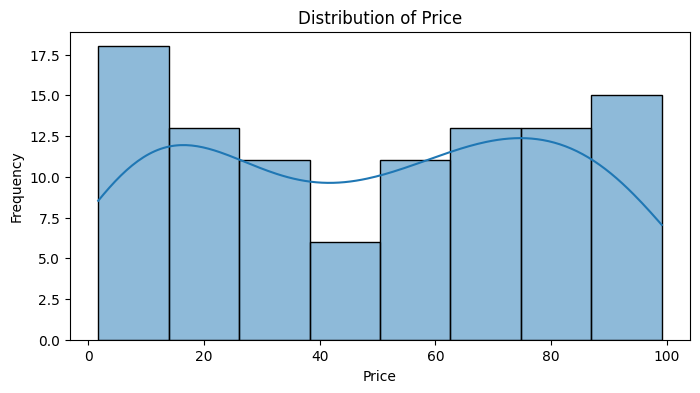

count    100.000000
mean      49.462461
std       31.168193
min        1.699976
25%       19.597823
50%       51.239831
75%       77.198228
max       99.171329
Name: Price, dtype: float64


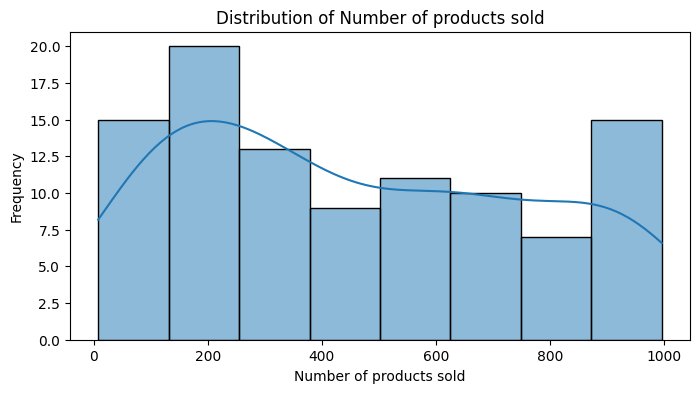

count    100.000000
mean     460.990000
std      303.780074
min        8.000000
25%      184.250000
50%      392.500000
75%      704.250000
max      996.000000
Name: Number of products sold, dtype: float64


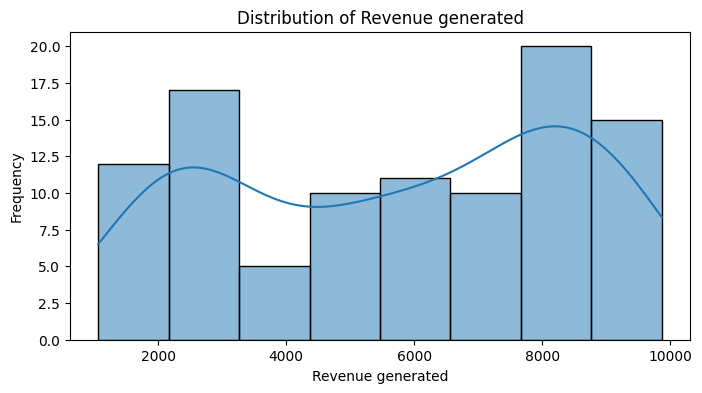

count     100.000000
mean     5776.048187
std      2732.841744
min      1061.618523
25%      2812.847151
50%      6006.352023
75%      8253.976921
max      9866.465458
Name: Revenue generated, dtype: float64


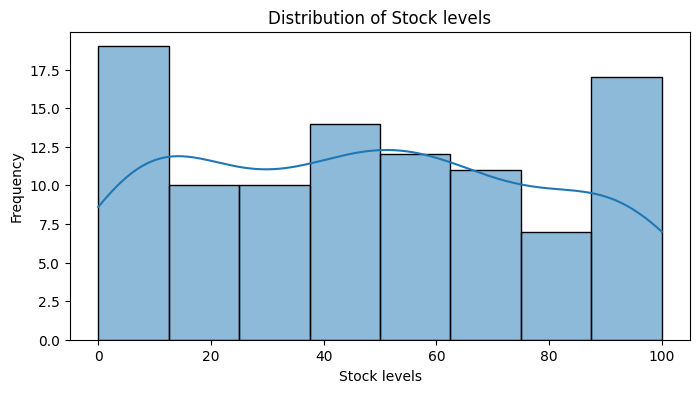

count    100.000000
mean      47.770000
std       31.369372
min        0.000000
25%       16.750000
50%       47.500000
75%       73.000000
max      100.000000
Name: Stock levels, dtype: float64


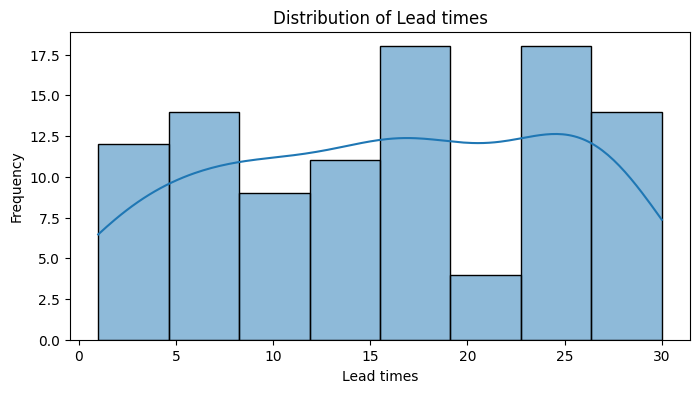

count    100.000000
mean      15.960000
std        8.785801
min        1.000000
25%        8.000000
50%       17.000000
75%       24.000000
max       30.000000
Name: Lead times, dtype: float64


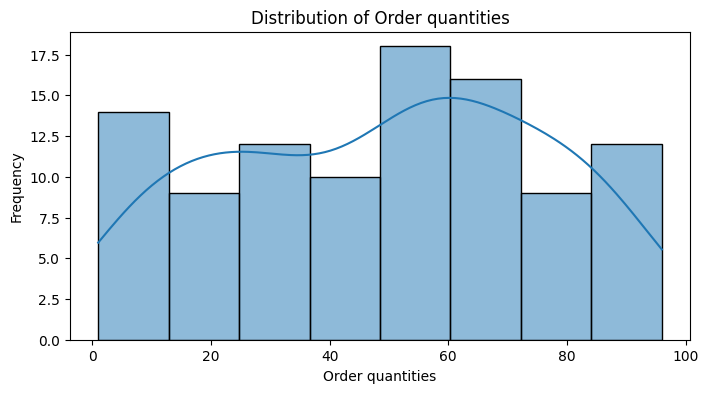

count    100.000000
mean      49.220000
std       26.784429
min        1.000000
25%       26.000000
50%       52.000000
75%       71.250000
max       96.000000
Name: Order quantities, dtype: float64


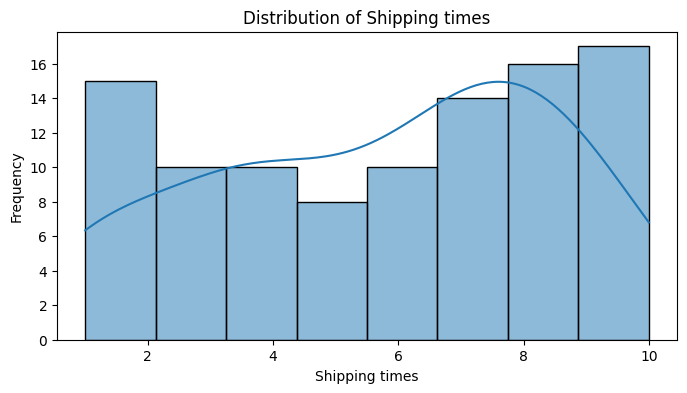

count    100.000000
mean       5.750000
std        2.724283
min        1.000000
25%        3.750000
50%        6.000000
75%        8.000000
max       10.000000
Name: Shipping times, dtype: float64


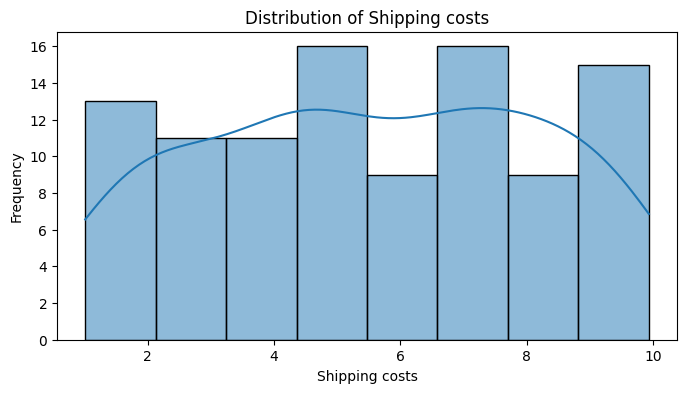

count    100.000000
mean       5.548149
std        2.651376
min        1.013487
25%        3.540248
50%        5.320534
75%        7.601695
max        9.929816
Name: Shipping costs, dtype: float64


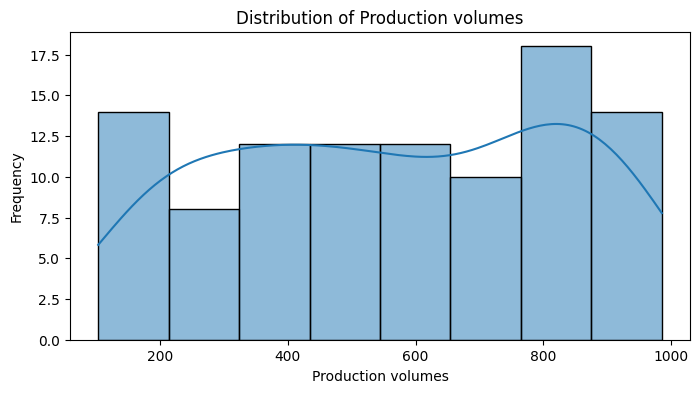

count    100.000000
mean     567.840000
std      263.046861
min      104.000000
25%      352.000000
50%      568.500000
75%      797.000000
max      985.000000
Name: Production volumes, dtype: float64


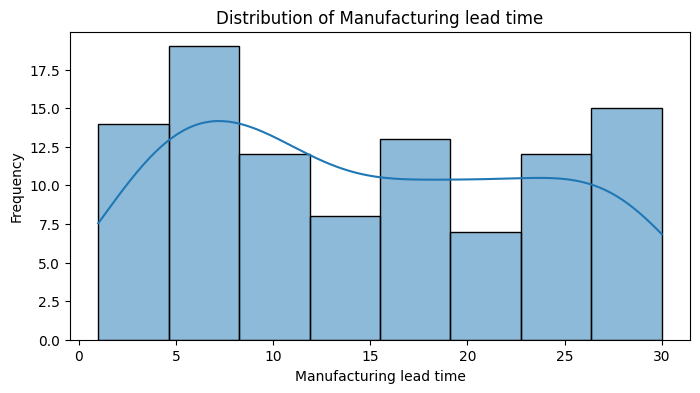

count    100.00000
mean      14.77000
std        8.91243
min        1.00000
25%        7.00000
50%       14.00000
75%       23.00000
max       30.00000
Name: Manufacturing lead time, dtype: float64


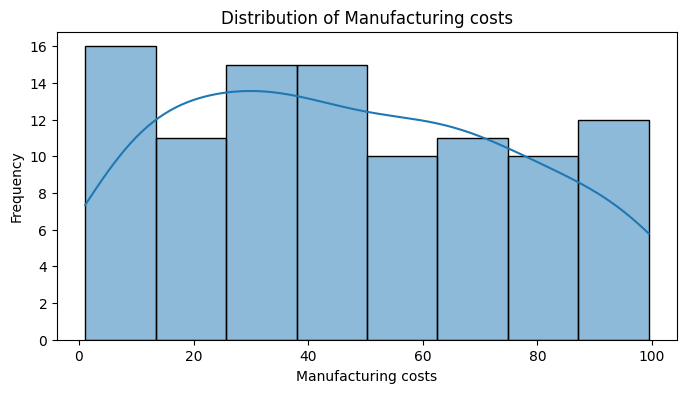

count    100.000000
mean      47.266693
std       28.982841
min        1.085069
25%       22.983299
50%       45.905622
75%       68.621026
max       99.466109
Name: Manufacturing costs, dtype: float64


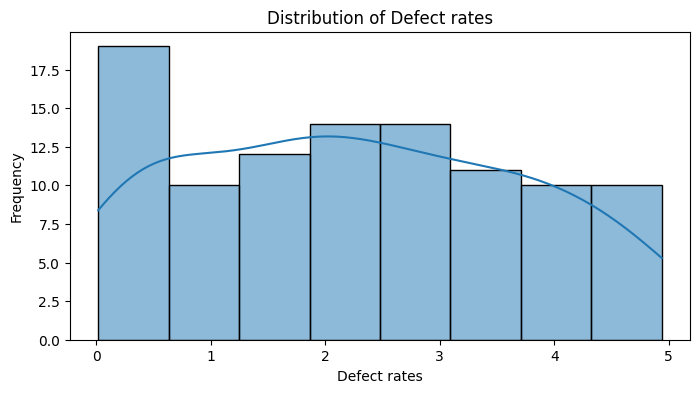

count    100.000000
mean       2.277158
std        1.461366
min        0.018608
25%        1.009650
50%        2.141863
75%        3.563995
max        4.939255
Name: Defect rates, dtype: float64


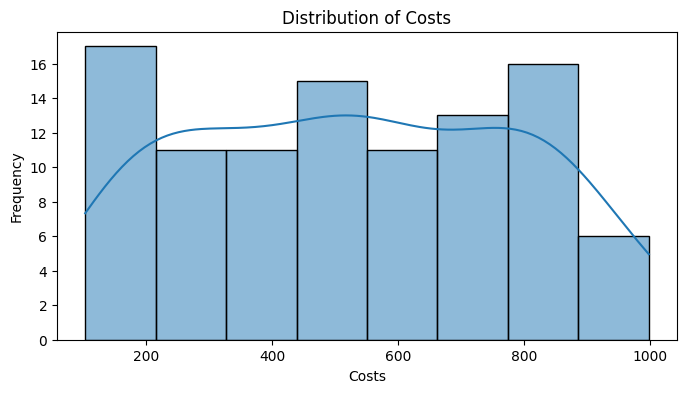

count    100.000000
mean     529.245782
std      258.301696
min      103.916248
25%      318.778455
50%      520.430444
75%      763.078231
max      997.413450
Name: Costs, dtype: float64


In [10]:
# 4. Analyze Numerical Feature Distributions
numerical_cols = ['Price', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']

for col in numerical_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
        print(df[col].describe())

## 5. Explore Categorical Feature Distributions
Visualize and summarize the distributions of categorical features like Product Type, SKU, Supplier name, Location, Shipping carriers, and Transportation modes.

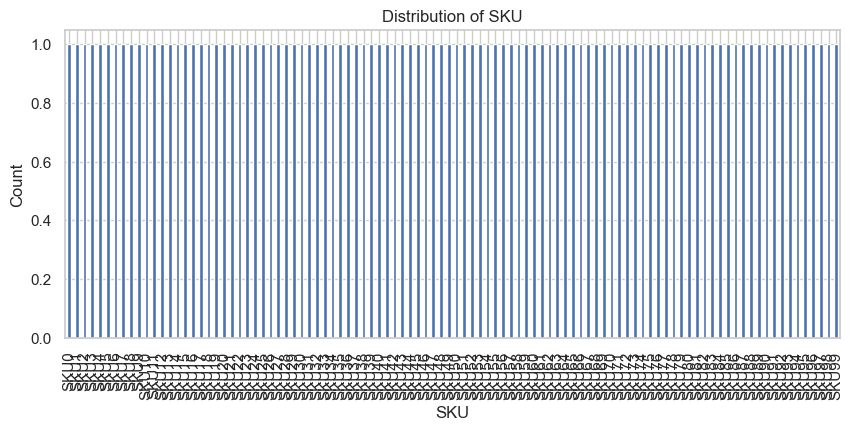

SKU
SKU0    1
SKU1    1
SKU2    1
SKU3    1
SKU4    1
Name: count, dtype: int64


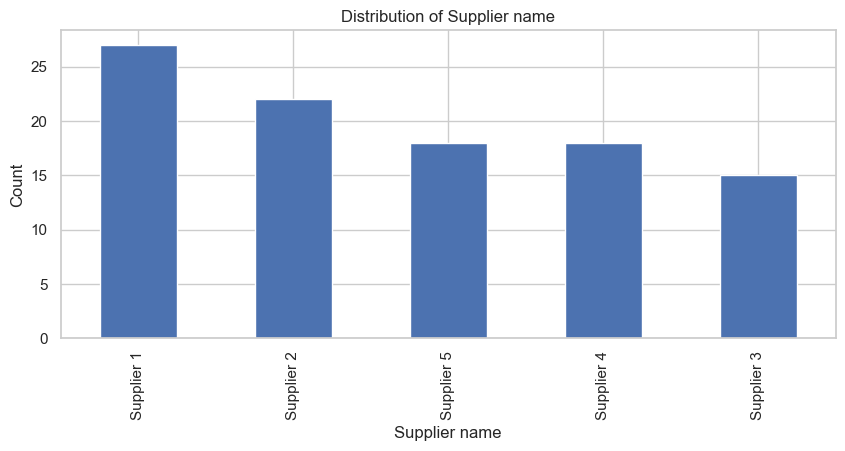

Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64


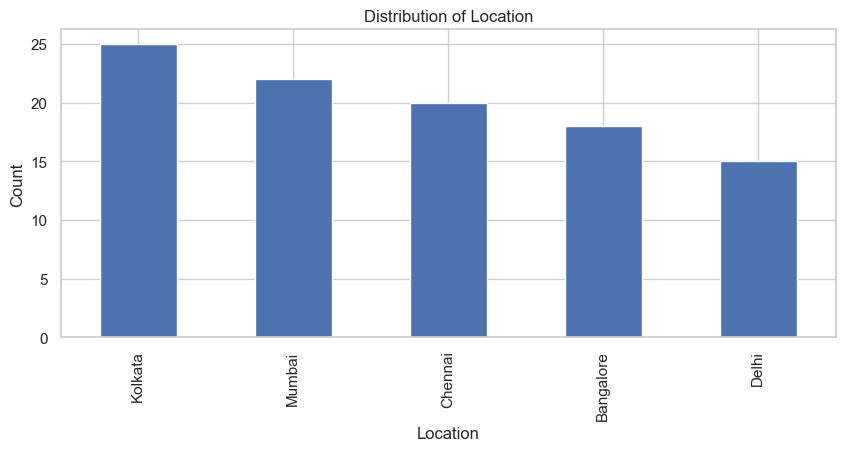

Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
Name: count, dtype: int64


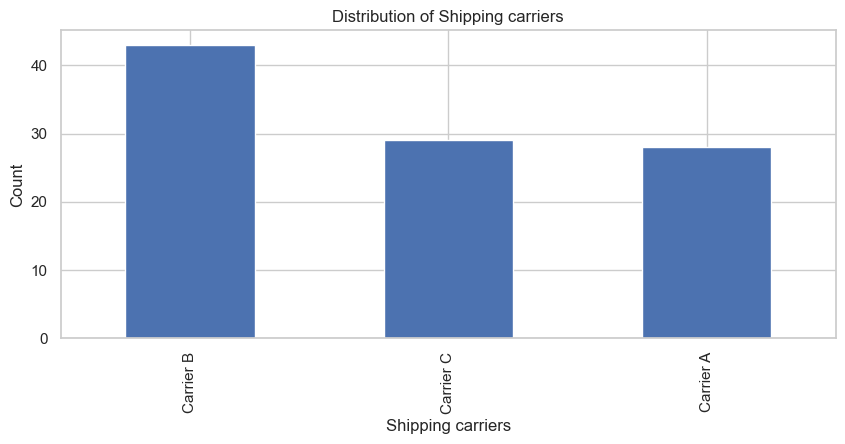

Shipping carriers
Carrier B    43
Carrier C    29
Carrier A    28
Name: count, dtype: int64


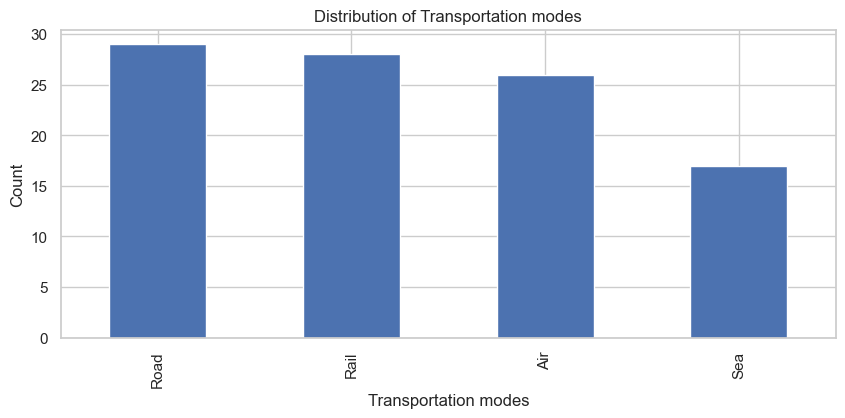

Transportation modes
Road    29
Rail    28
Air     26
Sea     17
Name: count, dtype: int64


In [16]:
# 5. Explore Categorical Feature Distributions
categorical_cols = ['Product Type', 'SKU', 'Supplier name', 'Location', 'Shipping carriers', 'Transportation modes']

for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()
        print(df[col].value_counts().head())

## 6. Identify Outliers and Anomalies
Detect and visualize outliers or anomalies in key columns (e.g., negative sales, extreme costs, implausible lead times) using boxplots or other methods.

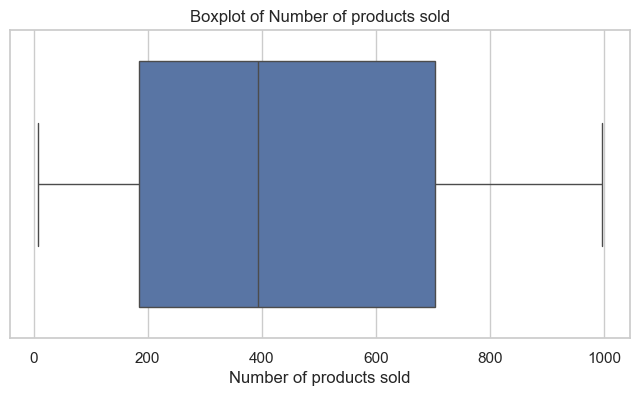

Negative values in Number of products sold: 0


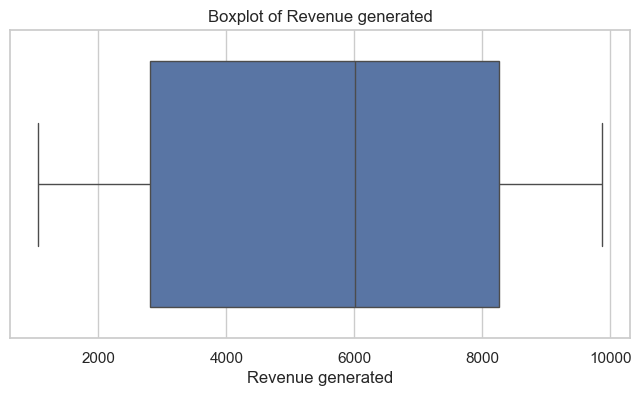

Negative values in Revenue generated: 0


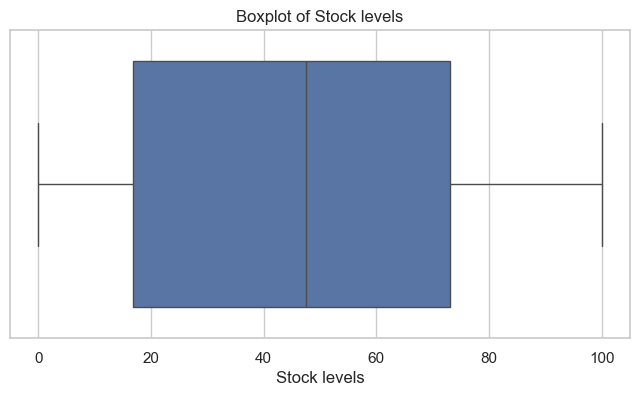

Negative values in Stock levels: 0


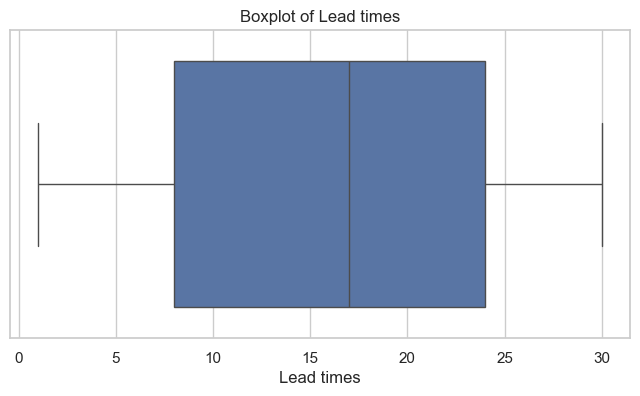

Negative values in Lead times: 0


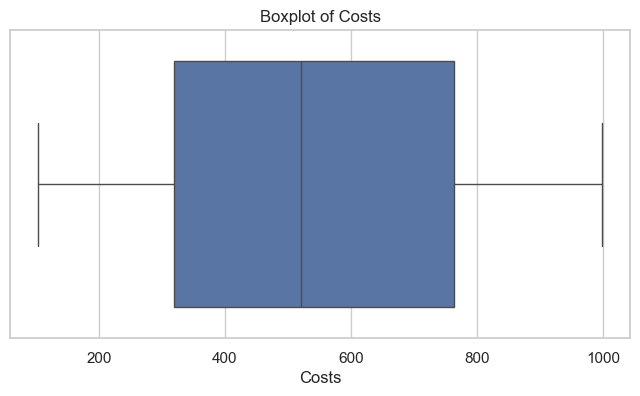

Negative values in Costs: 0


In [17]:
# 6. Identify Outliers and Anomalies
# Example: Boxplots for key numerical columns
for col in ['Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Costs']:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Boxplot of {col}')
        plt.show()
        # Check for negative or implausible values
        print(f"Negative values in {col}:", (df[col] < 0).sum())

## 7. Summarize Data Quality Issues
Document findings on missingness, duplicates, and inconsistencies in the dataset.

---

This concludes Phase 1: Data Exploration & Quality Assessment. The next phase will focus on feature relevance for demand forecasting and safety stock.

In [27]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [28]:
# Check for inconsistent categorical values (example for 'Product Type')
if 'Product Type' in df.columns:
    print("\nUnique Product Types:")
    print(df['Product Type'].unique())

In [29]:
# Check for negative or implausible values in key columns
for col in ['Number of products sold', 'Stock levels', 'Revenue generated', 'Costs', 'Lead times']:
    if col in df.columns:
        negatives = (df[col] < 0).sum()
        print(f"Negative values in {col}: {negatives}")

Negative values in Number of products sold: 0
Negative values in Stock levels: 0
Negative values in Revenue generated: 0
Negative values in Costs: 0
Negative values in Lead times: 0


# Conclusions: Data Quality & Structure Summary

- No missing values.
- No duplicate rows found in the dataset.
- No negative values in relevant columns.
- The following table summarizes each column: its name, data type, and number of unique values.


In [30]:
# Table: Column, Type, Unique Values
summary_table = pd.DataFrame({
    'Column': df.columns,
    'Type': [df[col].dtype for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns]
})
display(summary_table)

,Column,Type,Unique Values
0,Product type,str,3
1,SKU,str,100
2,Price,float64,100
3,Availability,int64,63
4,Number of products sold,int64,96
5,Revenue generated,float64,100
6,Customer demographics,str,4
7,Stock levels,int64,65
8,Lead times,int64,29
9,Order quantities,int64,61


In [16]:
def get_weekday(date_str):
    dt = datetime.datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
    return dt.strftime("%A")

get_weekday("2015-03-31 00:03:00")

'Tuesday'

In [17]:
("2015-03-31 00:03:00").split(" ")[0]

'2015-03-31'